# Vertical (FieldList): interpolating from hybrid to pressure levels

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import numpy as np

import earthkit.meteo.vertical.fieldlist as vertical

## Hybrid levels

## Getting the data

The input is GRIB data on 137 IFS model levels for one step. We fetch the file and extract temperature, specific humidity and the log surface pressure.

In [2]:
fl = ekd.from_source("sample", "tq_ml137_europe.grib2").to_fieldlist()

# LNSP → surface pressure [Pa]
lnsp = fl.sel({"parameter.variable": "lnsp", "vertical.level": 1})[0]
sp = lnsp.set(values=np.exp(lnsp.values))

t = fl.sel({"parameter.variable": "t"})  # temperature, 137 levels
q = fl.sel({"parameter.variable": "q"})  # specific humidity, 137 levels

t.head()

tq_ml137_europe.grib2:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,1,hybrid,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,2,hybrid,None,regular_ll
2,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,3,hybrid,None,regular_ll
3,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,4,hybrid,None,regular_ll
4,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5,hybrid,None,regular_ll


Please note that although ``lnsp`` is valid for the surface in our data it is available on hybrid level 1. This is how IFS forecast and analysis data is stored in ECMWF's MARS archive (from where our the data is originating).

The A and B coefficients defining the hybrid levels are embedded in the GRIB metadata and are inferred automatically.

## Using interpolate_hybrid_to_pressure_levels

In [3]:
target_p = [70000.0, 50000.0]  # Pa

t_res = vertical.interpolate_hybrid_to_pressure_levels(
    t,  # data to interpolate
    target_p,
    sp,
    interpolation="linear",
)
t_res.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,700.0,pressure,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,500.0,pressure,None,regular_ll


In [4]:
# the first 2 values from the resulting fields
t_res.values[:, :2]

array([[256.7211221 , 257.00983999],
       [244.06243185, 244.50014912]])

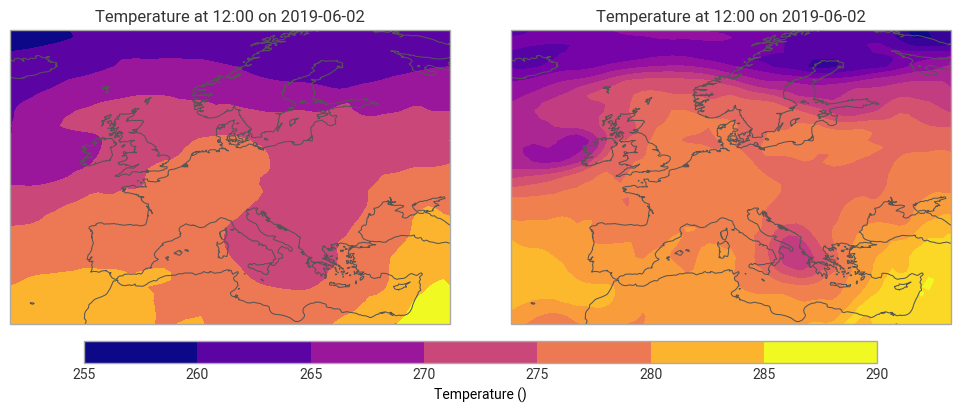

In [5]:
# plot the resulting fields
ekp.quickplot(t_res)

### Using a subset of levels

In [6]:
p_sub = vertical.pressure_on_hybrid_levels(sp, levels=[88], output="full")

# the max pressure on model level 88
p_sub[0].values.max()

np.float64(36971.49325737165)

Now we perform the interpolation by using only the lowest 50 model levels.

In [7]:
# keep only the 50 lowest model levels
t_sub = t.sel({"vertical.level": list(range(88, 138))})

t_res_sub = vertical.interpolate_hybrid_to_pressure_levels(
    t_sub,
    target_p,
    sp,
    interpolation="linear",
)
t_res_sub.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,700.0,pressure,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,500.0,pressure,None,regular_ll


In [8]:
# the first value from the resulting fields
t_res.values[:, 0]

array([256.7211221 , 244.06243185])

### Interpolating to a pressure field

In [9]:
pres_pv = ekd.from_source("sample", "pressure_on_pv_europe.grib1").to_fieldlist()[0]
pres_pv.ls()

pressure_on_pv_europe.grib1:   0%|          | 0.00/5.04k [00:00<?, ?B/s]

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,pres,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,2000,potential_vorticity,0,regular_ll


Next, we interpolate the data to the target field.

In [10]:
t_res_pv = vertical.interpolate_hybrid_to_pressure_levels(
    t,
    pres_pv,
    sp,
    interpolation="linear",
)

t_res_pv.ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,431.157539,pressure,None,regular_ll


Finally, plot the pressure of the 2 PVU potential vorticity level and the temperature interpolated to it side by side.

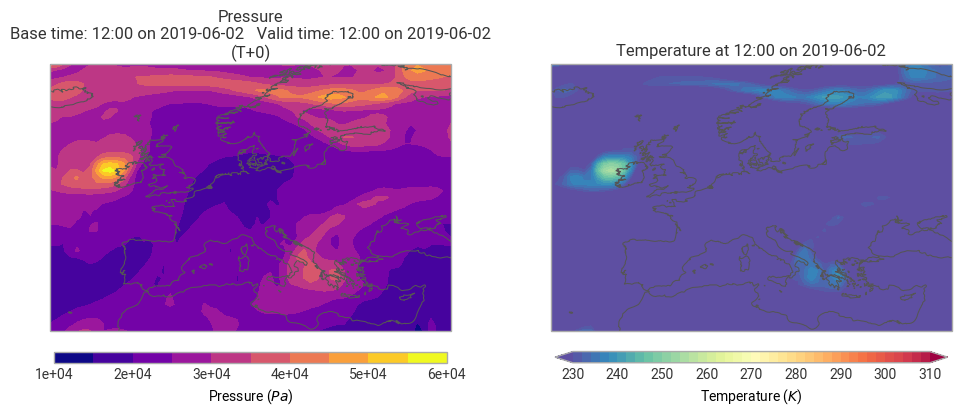

In [11]:
ekp.quickplot(ekd.FieldList.from_fields([pres_pv, t_res_pv]))

## Writing to GRIB

In [12]:
t_res.to_target("file", "_hybrid_to_pl.grib")

# read back and verify
ekd.from_source("file", "_hybrid_to_pl.grib").to_fieldlist().ls()

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,7,pressure,None,regular_ll
1,t,2019-06-02 12:00:00,2019-06-02 12:00:00,0 days,5,pressure,None,regular_ll
